# Explicabilité du modèle

## Partie A : Imports et chargement du pipeline (notebook 9)

Les données et les modèles finaux (déjà entraînés) sont rechargés depuis `../modelisation/pipeline_explicabilite.pkl`, généré à la fin du notebook 9.

In [18]:
import numpy as np
import pandas as pd
import shap
import joblib
import sys
import os

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions/modelisations"))

%load_ext autoreload
%autoreload 2

# On importe les fonctions utiles à la modélisation
from explicabilite import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# On recharge l'ensemble des données du notebook 09_modelisation.ipynb

globals().update(joblib.load("../modelisation/pipeline_explicabilite.pkl"))

# Charger le fichier dans une variable
pipeline = joblib.load("../modelisation/pipeline_explicabilite.pkl")

# Dépaqueter explicitement les variables dont tu as besoin
X_train = pipeline["X_train"]
X_val = pipeline["X_val"]
X_test = pipeline["X_test"]
X_en_cours = pipeline["X_en_cours"]
y_train = pipeline["y_train"]
y_val = pipeline["y_val"]
y_test = pipeline["y_test"]
y_en_cours = pipeline["y_en_cours"]
df_train = pipeline["df_train"]
df_val = pipeline["df_val"]
df_test = pipeline["df_test"]
df_en_cours = pipeline["df_en_cours"]
modeles_finaux = pipeline["modeles_finaux"]
meta = pipeline["meta"]
colonne_cible = pipeline["colonne_cible"]
RANDOM_STATE = pipeline["RANDOM_STATE"]

## Partie B : Feature importance

In [20]:
modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost (log)"],
        modeles_finaux["LightGBM (log)"],
        modeles_finaux["CatBoost (log)"]
    ],
    meta_model=meta
)

df_importances = calculer_permutation_importance(modele_stack, X_val, y_val)

Permutation feature importance :
                       Feature  Importance_Mean  Importance_Std
0               log_prev_value         0.396603             0.0
1             Team Success_onG         0.125876             0.0
2                          age         0.082385             0.0
3                   classement         0.054974             0.0
4                 pic_distance         0.018431             0.0
..                         ...              ...             ...
141               Starts_Compl        -0.000172             0.0
142  injury_minor_unknown_nb_d        -0.000225             0.0
143     injury_musculaire_nb_m        -0.000553             0.0
144                         xa        -0.001638             0.0
145                 xg_buildup        -0.004091             0.0

[146 rows x 3 columns]


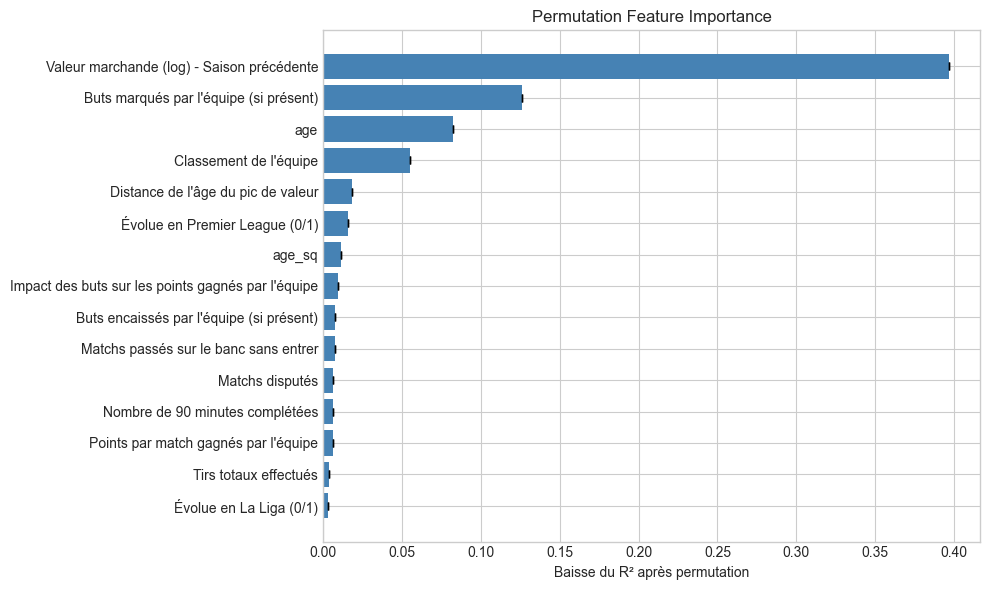

In [21]:
top15_df = afficher_top_features_importance(
    df_importances=df_importances,
    dict_variables=DICT_VARIABLES,
    top_n=15
)

## Partie C : Les analyses SHAP

### C1 : L'explicabilité globale du modèle


Shap du stacking final :


Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.


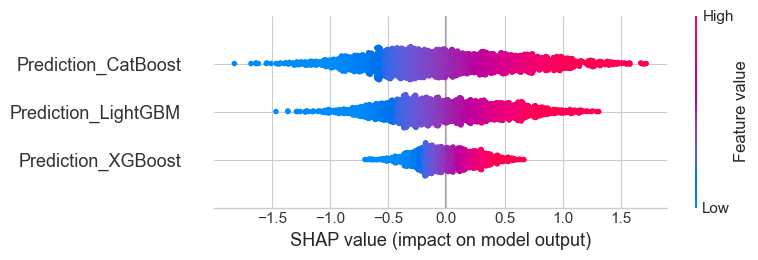

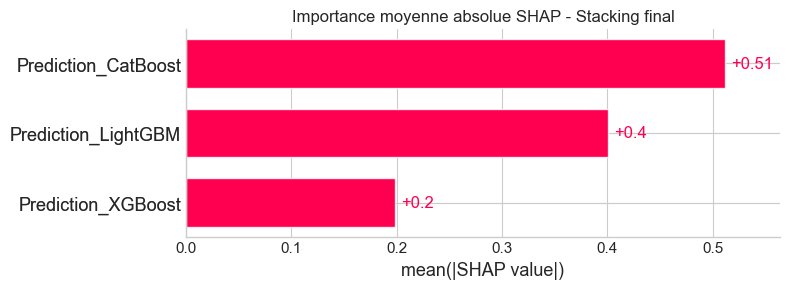


Explication locale de la prédiction à l'index 0 du jeu de validation


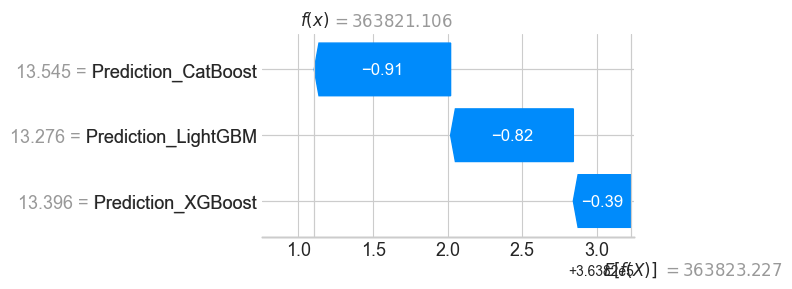

In [22]:
shap_vals = analyser_shap_stacking(meta, modeles_finaux, X_val)

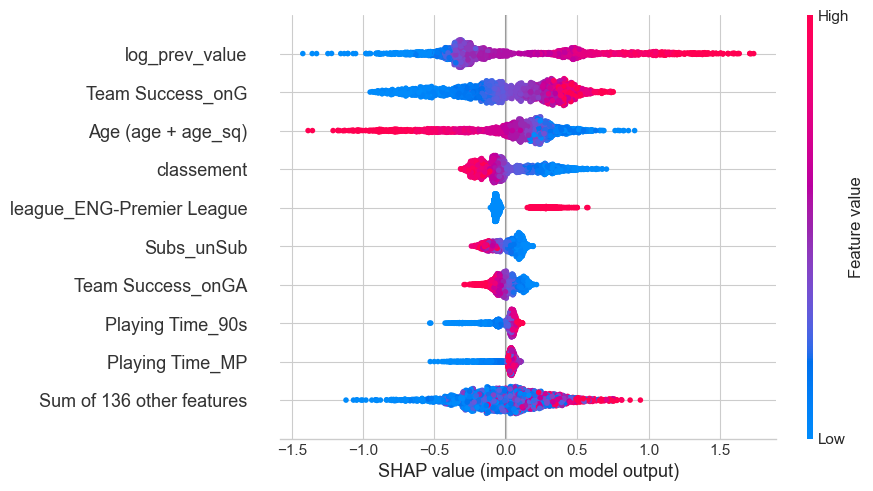

In [23]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost (log)"])

shap_values_xgb = explainer_xgb(X_val)

groupes = {"Age (age + age_sq)": ["age", "age_sq"]}

shap_values_xgb_grouped = regrouper_shap(shap_values_xgb, groupes)

shap.plots.beeswarm(shap_values_xgb_grouped)

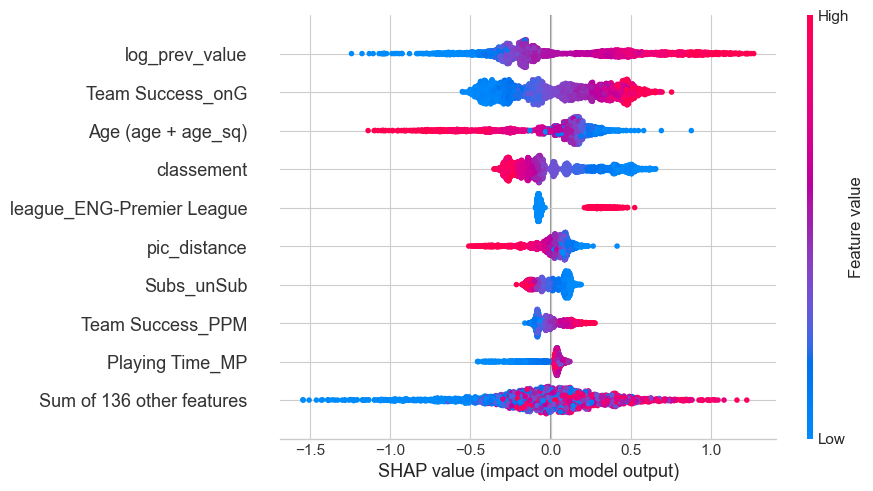

In [24]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost (log)"])
shap_values_cb = explainer_cb(X_val)

shap_values_cb_grouped = regrouper_shap(shap_values_cb, groupes)

shap.plots.beeswarm(shap_values_cb_grouped)

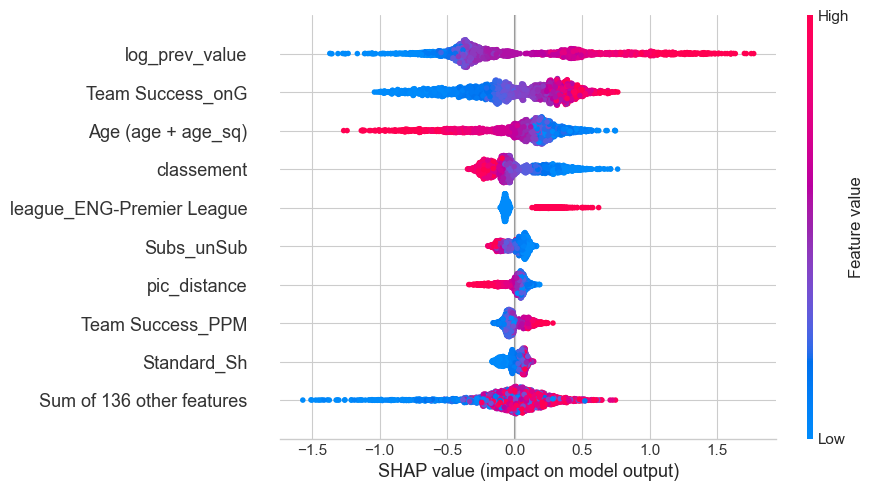

In [25]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM (log)"])
shap_values_lgb = explainer_lgb(X_val)

shap_values_lgb_grouped = regrouper_shap(shap_values_lgb, groupes)

shap.plots.beeswarm(shap_values_lgb_grouped)

### C2 : Explicabilité locale

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:476: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


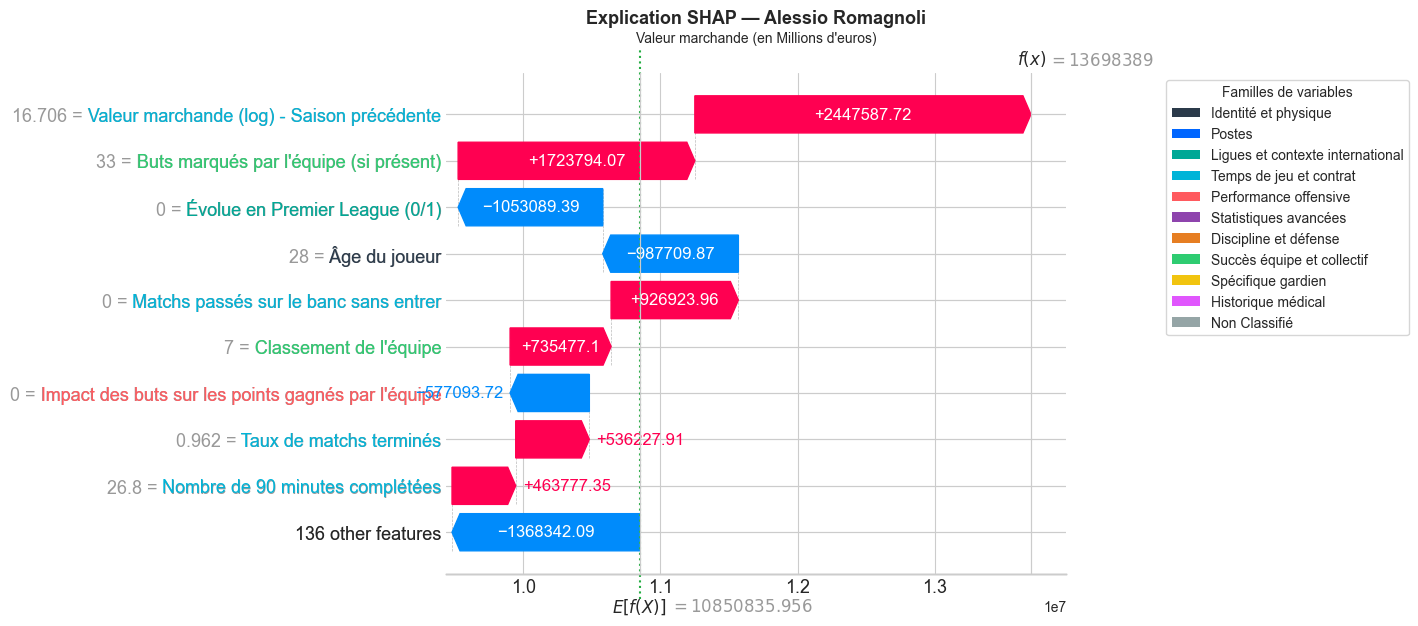

In [26]:
shap_j = afficher_waterfall_shap_joueur(
    modeles_finaux=modeles_finaux,
    X_val=X_val,
    df_val=df_val,
    groupes=groupes,
    palette_pro=PALETTE_PRO,
    indice_joueur=90
)

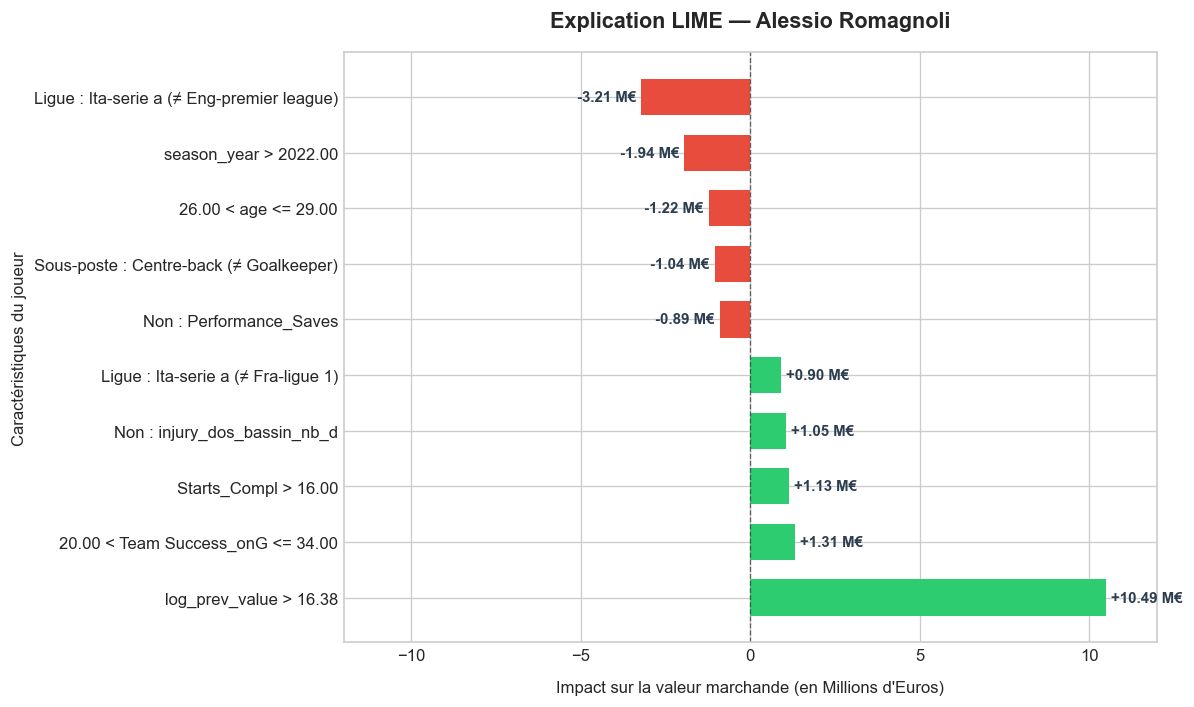

In [27]:
df_lime_res = explications_lime_joueur(
    model=modeles_finaux["XGBoost (log)"],
    X_train=X_train,
    X_val=X_val,
    df_val=df_val,
    indice_joueur=90
)

## Partie D : Trajectoires de valeur marchande : groupes de joueurs similaires

Objectif : identifier des groupes de joueurs dont la valeur marchande évolue de façon similaire
d'une saison à l'autre, quantifier ces variations (€ et %), puis expliquer (SHAP local puis global)
ce qui caractérise chaque groupe. Le but final est un support de storytelling permettant de conseiller
un club selon sa stratégie : **plus-value** (dénicher un profil qui va prendre de la valeur) ou
**performance immédiate** (recruter un profil déjà performant, quitte à payer plus cher).

Comme le split train/val/test/en_cours est **temporel**, un même joueur peut apparaître dans plusieurs
de ces jeux selon l'année. On reconstitue donc d'abord un historique complet par joueur, toutes saisons
confondues, avant de calculer les trajectoires et de faire du clustering.

### D1 : Reconstitution de l'historique complet par joueur (toutes saisons, tous splits)

In [28]:
df_historique = reconstituer_historique(df_train = df_train, df_val = df_val, df_test = df_test,
                                        df_en_cours = df_en_cours, colonne_cible = colonne_cible)

5117 joueurs uniques sur 6 saisons.


### D2 : Écarts de valeur marchande d'une saison à l'autre

In [29]:
df_historique = calculer_ecarts_saisons(df_historique=df_historique, colonne_cible = colonne_cible)

### D3 : Constitution des groupes de joueurs à trajectoires similaires (clustering)

In [30]:
stats_joueurs, model_km, scaler_km, scores, X_cluster = segmenter_trajectoires_joueurs(
    df_historique=df_historique,
    colonne_cible=colonne_cible,
    colonne_joueur="player",
    n_clusters=4,
    random_state=RANDOM_STATE
)

Nombre de joueurs retenus pour la classification : 1517 (sur 3226 au total).

Silhouette score par nombre de clusters :
  k=2 : 0.467
  k=3 : 0.377
  k=4 : 0.346  <-- nombre de clusters actuel
  k=5 : 0.298
  k=6 : 0.312
  k=7 : 0.314
  k=8 : 0.298

Répartition des joueurs par cluster
                            Effectif  Proportion (%)
profil_metier                                       
Rotation / valeur modeste        718            47.3
Cadres en progression            468            30.9
Superstars en forte hausse       126             8.3
Stars post-pic en repli          205            13.5

Statistiques de trajectoire par cluster
                           mean_delta_moyen std_delta_moyen  vm_moyenne  \
profil_metier                                                             
Rotation / valeur modeste      -1167638.0 €     2014338.0 €   3342131.0   
Cadres en progression           1464078.0 €     6582023.0 €  19101496.0   
Superstars en forte hausse     10509418.0 €    15837176

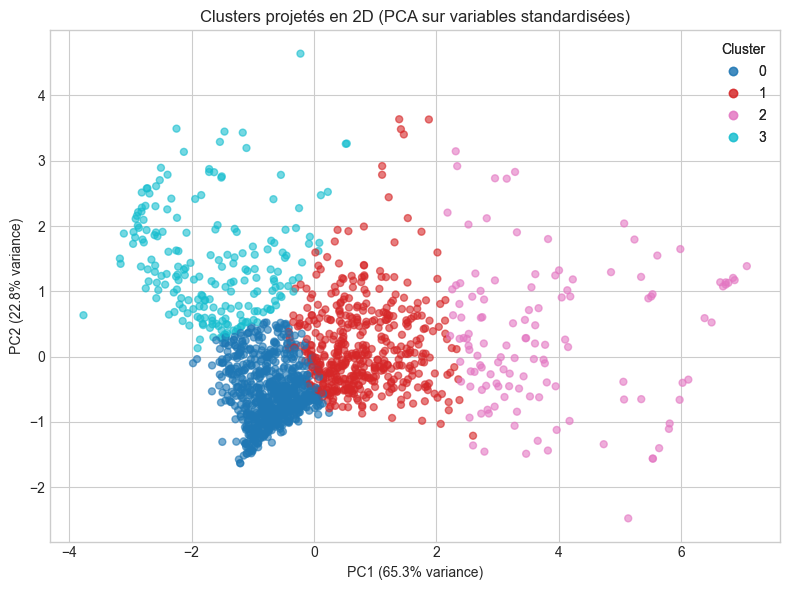

Variance totale expliquée par PC1+PC2 : 88.2%



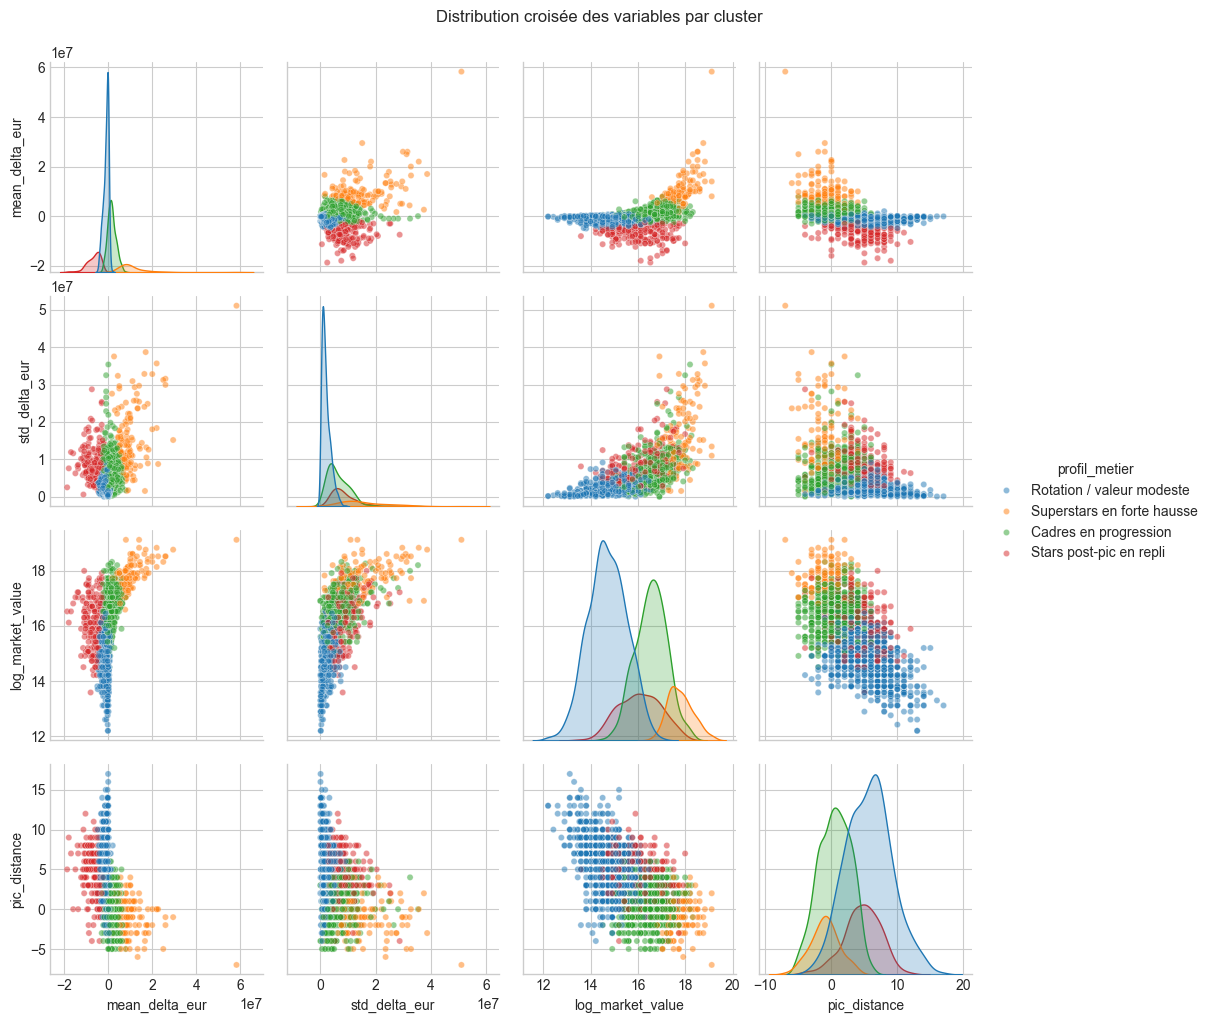

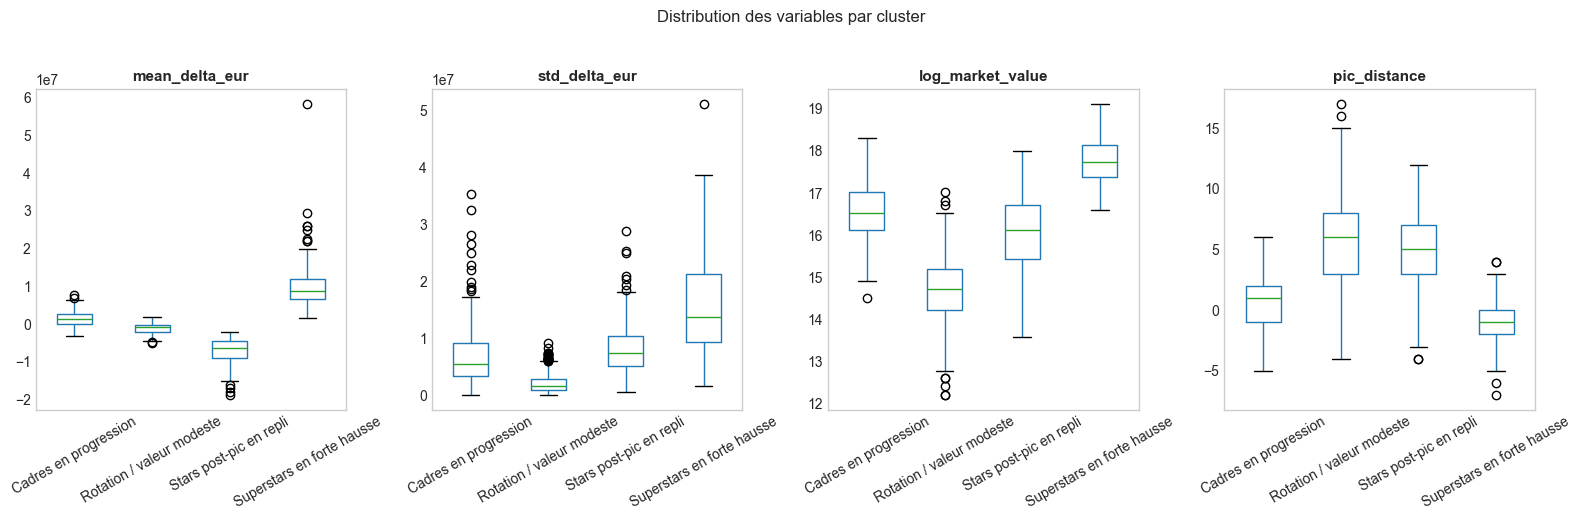

In [31]:
res_visu = visualiser_clusters_trajectoires(
    stats_joueurs=stats_joueurs,
    X_cluster=X_cluster,
    random_state=RANDOM_STATE
)

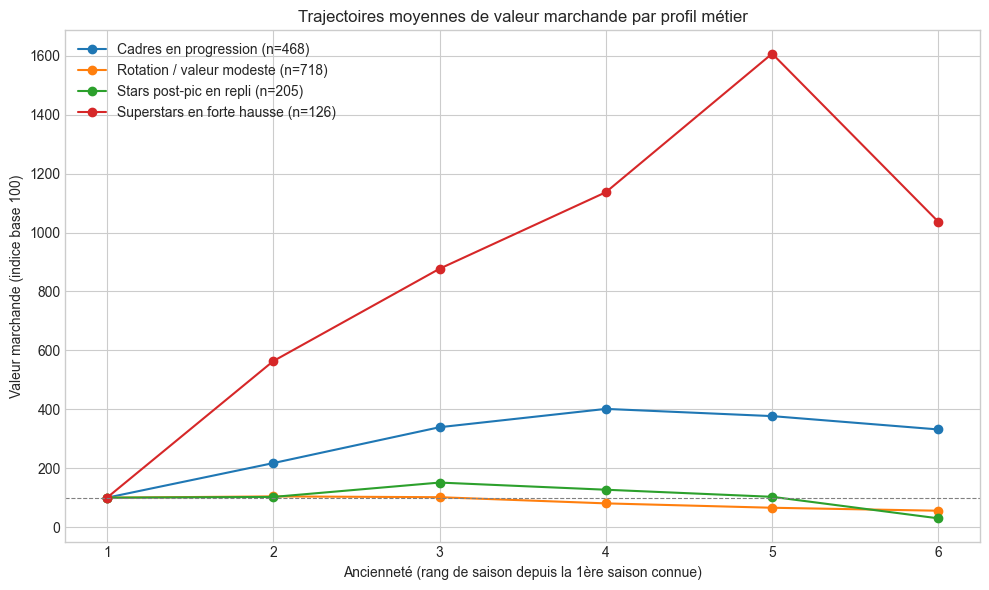

In [32]:
df_traj_res = tracer_trajectoires_moyennes_vm(
    df_historique=df_historique,
    stats_joueurs=stats_joueurs,
    seuil_min_joueurs=30
)

### D4 : Explicabilité locale — un même joueur, année après année (SHAP)

On choisit un joueur représentatif d'un groupe , et on
affiche le waterfall SHAP pour **chaque saison où il est présent dans le dataset**, quel que soit le
split d'origine (train/val/test/en_cours).

Étude du joueur : Kylian Mbappé
Saisons disponibles pour Kylian Mbappé : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


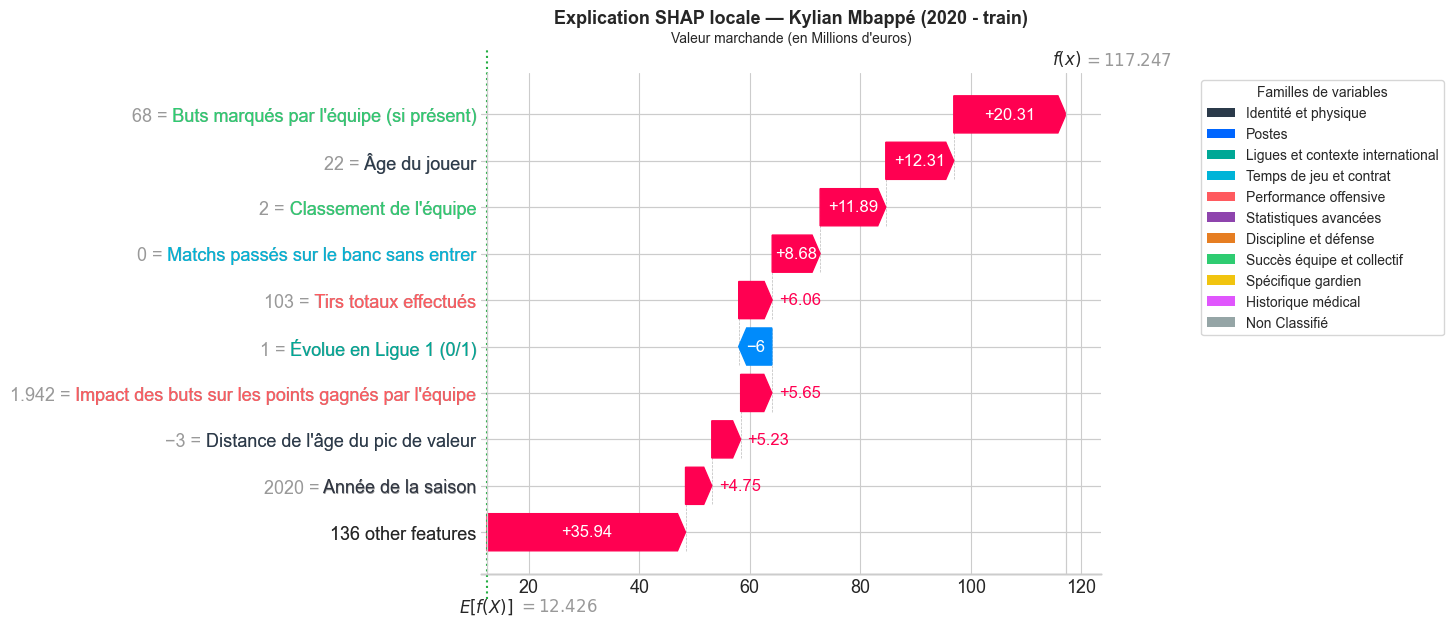

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


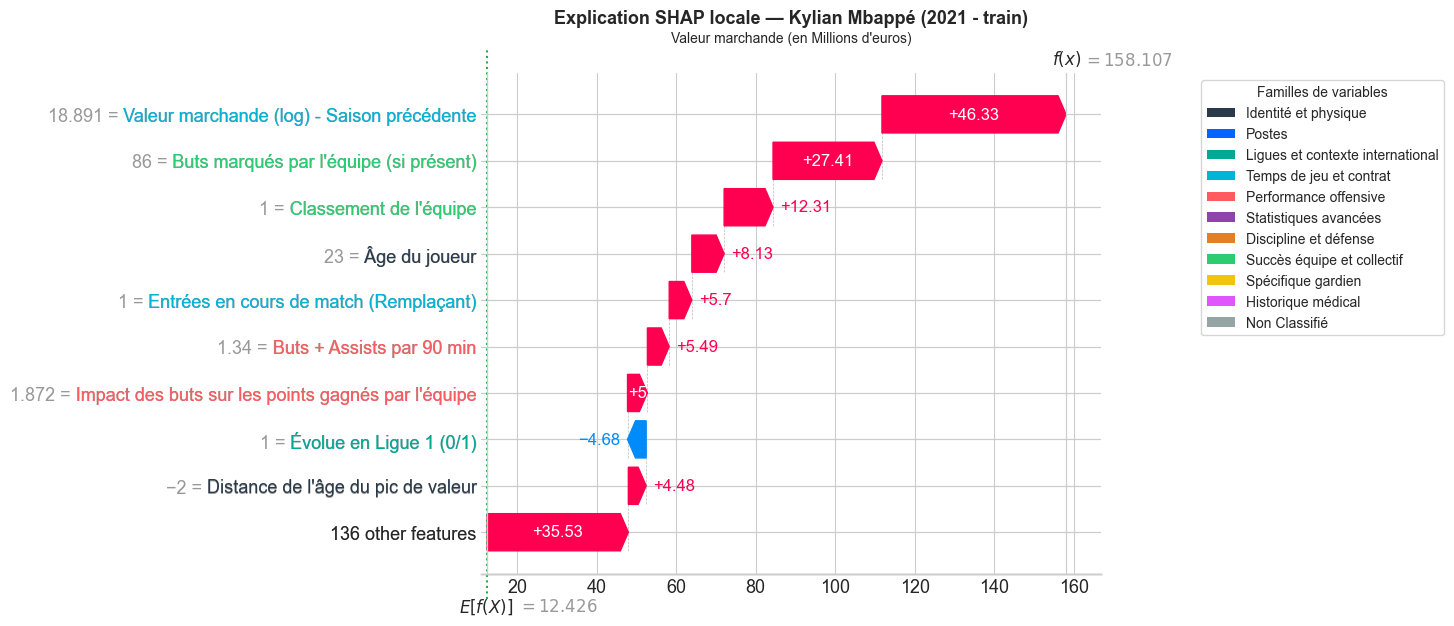

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


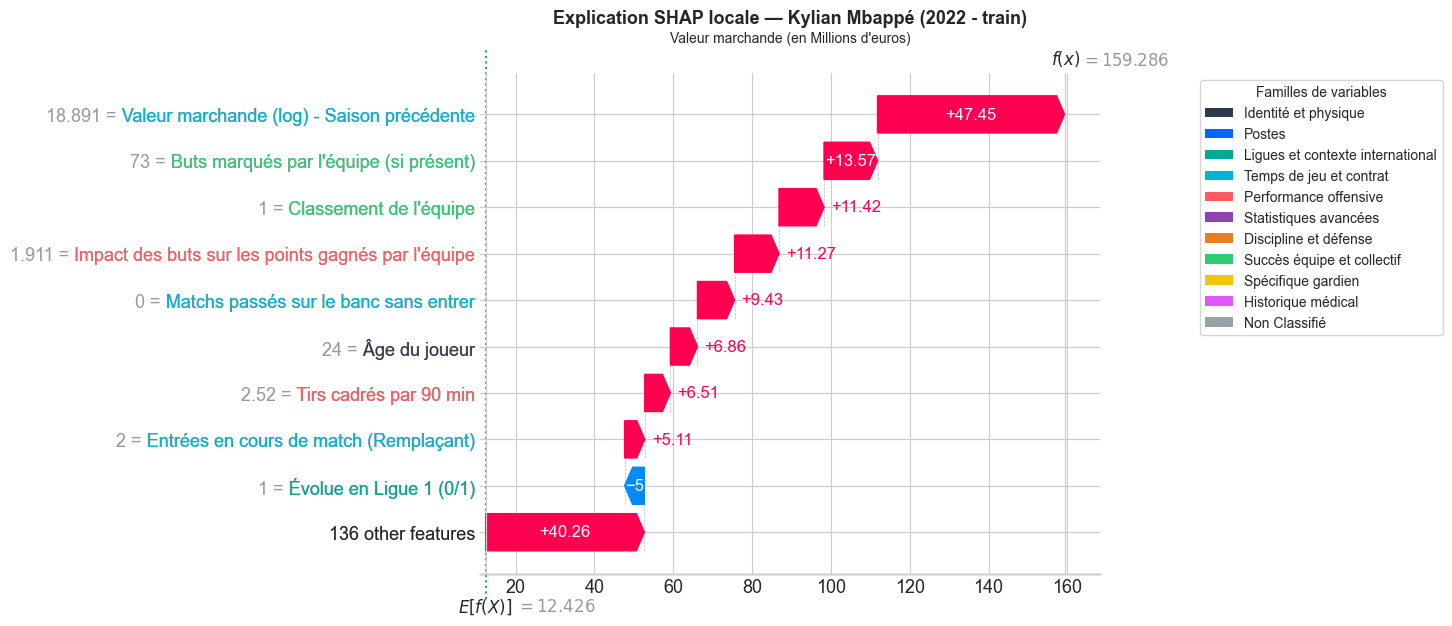

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


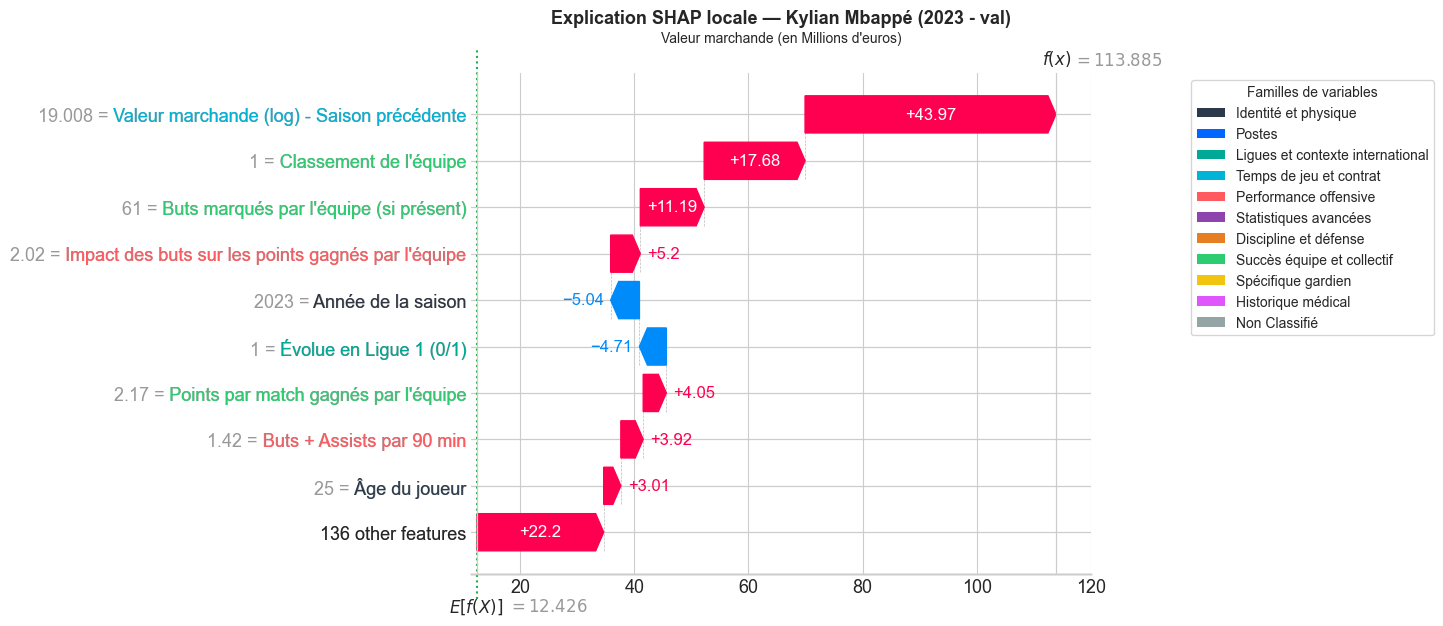

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


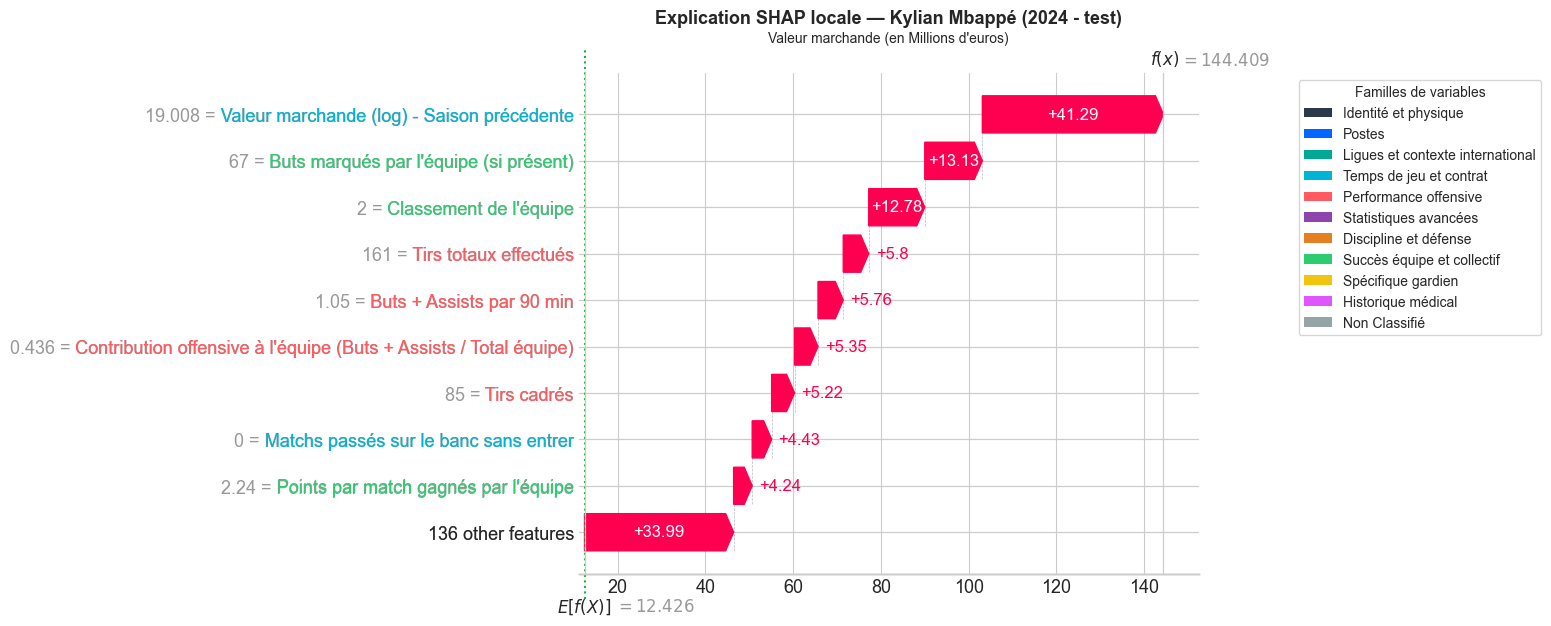

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


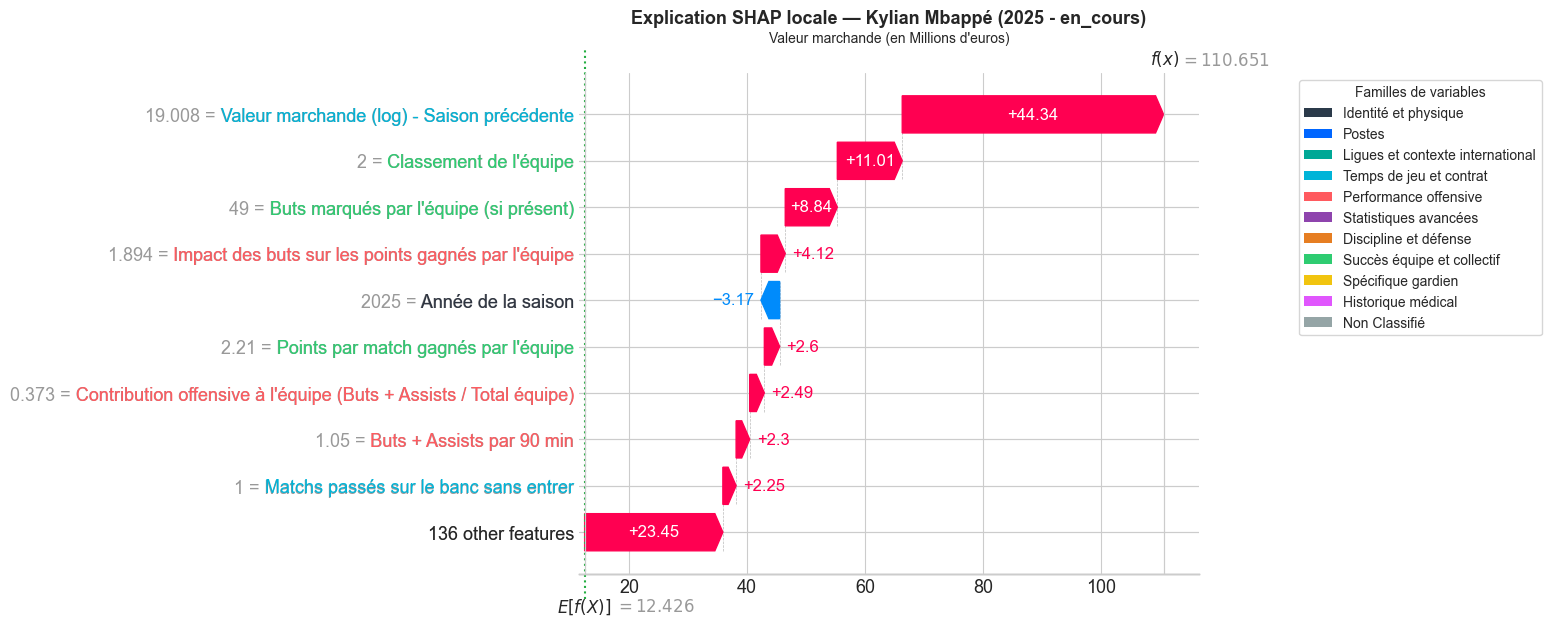

In [33]:
dict_datasets = {
    "train": (df_train, X_train),
    "val": (df_val, X_val),
    "test": (df_test, X_test),
    "en_cours": (df_en_cours, X_en_cours),
}

res = analyser_explications_shap_joueur(
    joueur_etudie="Kylian Mbappé",
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    palette_pro=PALETTE_PRO,
)

### D5 : Explicabilité globale du groupe (SHAP agrégé)

On agrège les explications SHAP sur l'ensemble des joueurs du groupe (une ligne = dernière saison
connue de chaque joueur du groupe) pour faire ressortir le **profil type** : quelles variables
expliquent, en moyenne, la valeur marchande de ce type de joueur.

#### D5.1 : Cluster « Rotation / valeur modeste »

718 joueurs inclus dans l'explicabilité globale du profil « Rotation / valeur modeste ».


PermutationExplainer explainer: 719it [48:07,  4.03s/it]                          


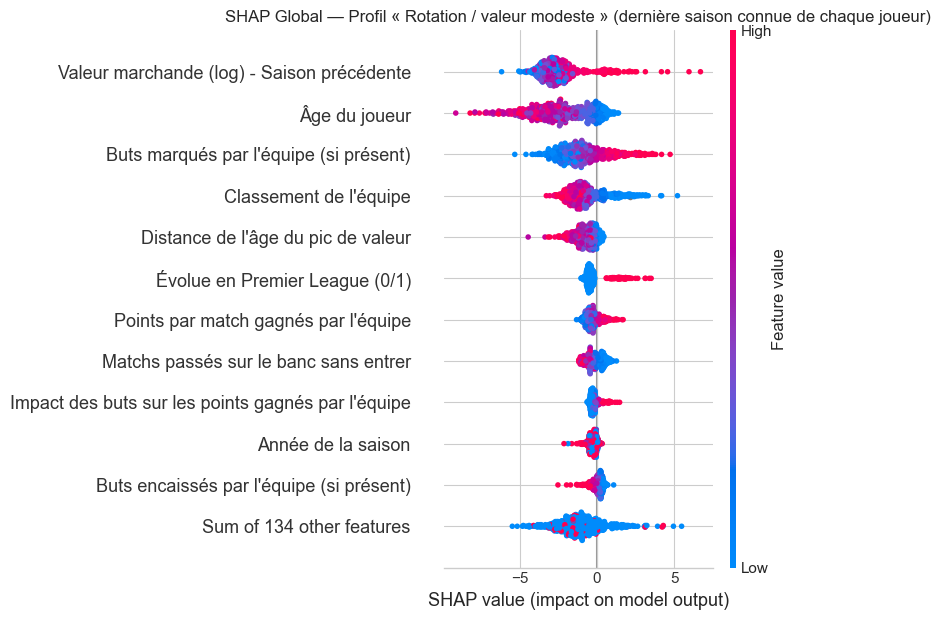

In [34]:
shap_global_res = analyser_explicabilite_globale_groupe(
    groupe_etudie="Rotation / valeur modeste",
    df_clusters=stats_joueurs.reset_index(),
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    max_display=12
)

**Profil de joueurs représenté :** des joueurs à valeur marchande faible (≈ 3,9 M€ en moyenne) et globalement stable à légèrement en baisse (-1,1 M€/saison en moyenne, faible volatilité). Il y a peu de stars, beaucoup de joueurs installés dans des clubs modestes ou en fin de progression.

**Ce que dit le SHAP global :**
- La **valeur marchande de la saison précédente** est le facteur le plus important, mais avec une amplitude d'impact bien plus faible que sur les clusters à forte valeur.
- L'**âge** est le deuxième facteur et joue **négativement dès qu'il augmente** (points rouges très à gauche,
  jusqu'à -10) : c'est le facteur le plus discriminant de ce groupe, bien plus que sur les autres profils.
- Le **niveau de l'équipe** pèse moins : la performance collective tire peu la valeur vers le haut, signe de joueurs qui ne sont pas le moteur de leur équipe.
- Jouer en **Premier League** reste positif mais avec un impact contenu comparé aux autres groupes.

**Stratégie de recrutement associée :** ce sont des joueurs à recruter si le club veut beaucoup de joueurs peu chers, ou s'ils souhaitent réaliser une potentielle **plus-value** : à l'intérieur de ce cluster, cibler spécifiquement les
joueurs jeunes (points bleus sur "Âge du joueur", loin d'avoir un impact négatif) plutôt que les plus
âgés, qui tirent mécaniquement le cluster vers le bas.

#### D5.2 : Cluster « Cadres en progression »

468 joueurs inclus dans l'explicabilité globale du profil « Cadres en progression ».


PermutationExplainer explainer: 469it [28:20,  3.66s/it]                         


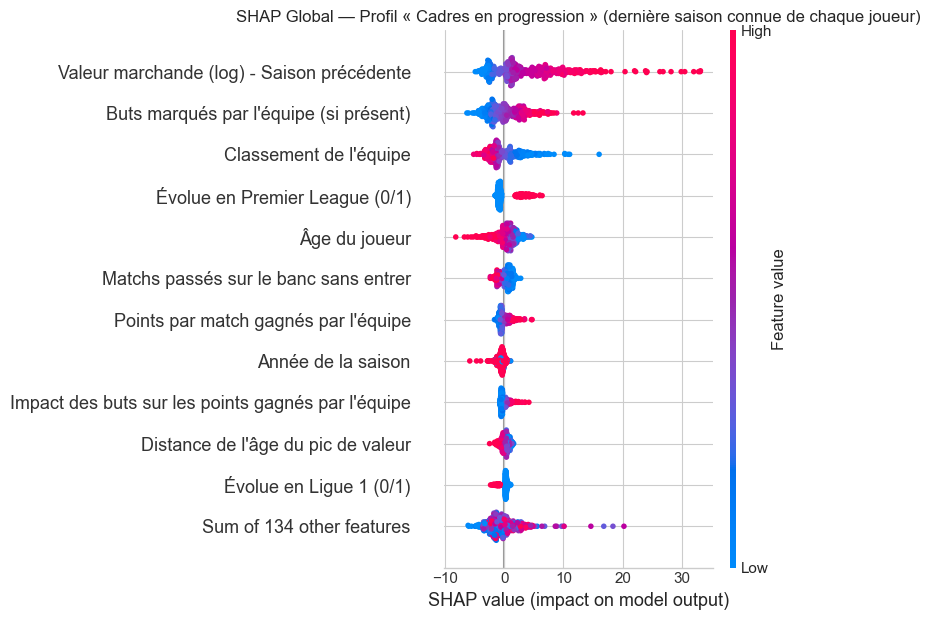

In [35]:
shap_global_res = analyser_explicabilite_globale_groupe(
    groupe_etudie="Cadres en progression",
    df_clusters=stats_joueurs.reset_index(),
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    max_display=12
)

**Profil de joueurs représenté :** des joueurs déjà installés à un bon niveau de valeur (≈ 21,3 M€ en
moyenne) et **en croissance régulière** (+1,9 M€/saison en moyenne). Ce sont des cadres confirmés,
plutôt en pleine maturité de carrière, qui continuent de prendre de la valeur saison après saison.

**Ce que dit le SHAP global :**
- La **valeur marchande N-1** est le facteur le plus important, avec une amplitude d'impact plus forte que dans le cluster « Rotation ».
- Le **classement de l'équipe** et les **buts marqués par l'équipe** pèsent beaucoup plus que dans le
  cluster précédent : la performance collective du club tire ici la valeur individuelle vers le haut, signe
  de joueurs qui sont dans d'importantes d'équipes qui performent.
- **Évoluer en Premier League** a un impact positif important (les points rouges "oui" sont
  clairement à droite), ce qui traduit une prime de valorisation forte associée à ce championnat pour ce
  profil.
- Contrairement au cluster « Rotation », l'**âge** joue ici plutôt **positif ou neutre** : ce sont des
  joueurs en pleine maturité, pas encore pénalisés par l'approche de la fin de carrière.

**Stratégie de recrutement associée :** profil de choix pour une stratégie de **performance immédiate** —
le joueur est déjà performant, dans une équipe qui gagne, et sa valeur continue de progresser. Le coût
d'acquisition sera élevé mais le risque de perte de valeur à court terme est faible. C'est un profil à
privilégier pour renforcer un effectif qui vise des résultats immédiats plutôt qu'un pari sur le potentiel.


#### D5.3 : Cluster « Stars post-pic en repli »

205 joueurs inclus dans l'explicabilité globale du profil « Stars post-pic en repli ».


PermutationExplainer explainer: 206it [11:22,  3.38s/it]                         


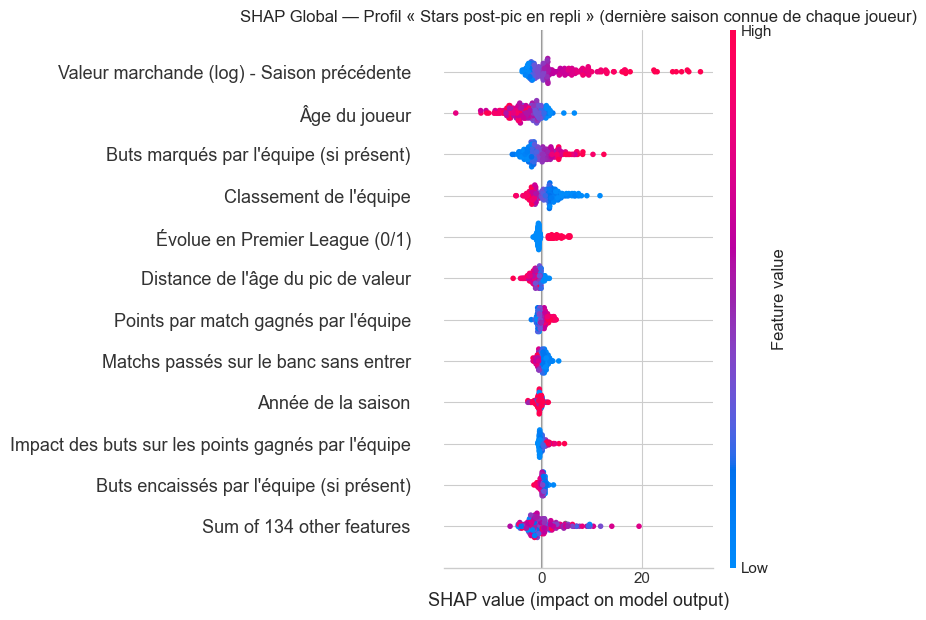

In [36]:
shap_global_res = analyser_explicabilite_globale_groupe(
    groupe_etudie="Stars post-pic en repli",
    df_clusters=stats_joueurs.reset_index(),
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    max_display=12
)

**Profil de joueurs représenté :** des joueurs à valeur encore élevée (≈ 14,7 M€ en moyenne) mais dont la
valeur **chute fortement** (-7,0 M€/saison en moyenne). Ce sont d'anciennes valeurs sûres qui ont dépassé leur pic et dont le marché réévalue le potentiel à la baisse.

**Ce que dit le SHAP global :**
- L'**âge** est ici le facteur le plus punitif du dataset : les points rouges (âge élevé) sont les plus
  extrêmes à gauche de tous les clusters, avec un impact négatif marqué.
- La **distance à l'âge du pic** va dans le même sens : plus le joueur s'éloigne de son pic de valeur,
  plus l'impact est négatif.
- Le **classement de l'équipe** et les **buts marqués** ont encore un poids important, ce qui montre que
  ces joueurs restent souvent dans des clubs qui performent (ils n'ont pas encore été "relégués" vers des
  clubs plus modestes), mais cela ne suffit plus à compenser l'effet de l'âge.

**Stratégie de recrutement associée :** il faut analyser ces joueurs avec prudence. Deux lectures possibles selon
l'objectif du club : (1) **éviter** ces profils si l'objectif est la revente à plus-value — la tendance est défavorable ; (2) les cibler ponctuellement pour une stratégie de **performance immédiate à coût réduit** (joueur encore utile sportivement, prix d'achat tiré vers le bas par la dépréciation), typiquement en fin de contrat avant que la valeur ne s'effondre davantage.

#### D5.4 : Cluster « Superstars en forte hausse »

126 joueurs inclus dans l'explicabilité globale du profil « Superstars en forte hausse ».


PermutationExplainer explainer: 127it [07:15,  3.54s/it]                         


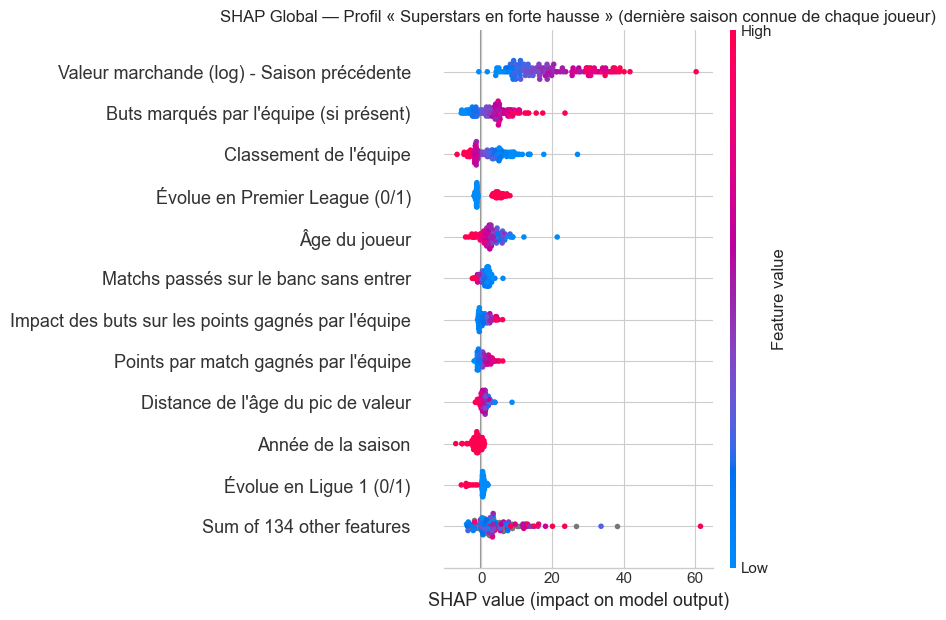

In [37]:
shap_global_res = analyser_explicabilite_globale_groupe(
    groupe_etudie="Superstars en forte hausse",
    df_clusters=stats_joueurs.reset_index(),
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    max_display=12
)

**Profil de joueurs représenté :** le cluster le plus extrême : valeur marchande déjà très élevée (≈ 68,3 M€ en moyenne) et **en très forte croissance** (+12,1 M€/saison en moyenne), avec aussi la plus forte volatilité du dataset (±15,9 M€) — cohérent avec des trajectoires de superstars, où quelques saisons exceptionnelles peuvent faire bondir la valeur de plusieurs dizaines de millions.

**Ce que dit le SHAP global :**
- La **valeur marchande N-1** a une amplitude d'impact hors norme : l'effet d'ancrage/de rareté domine largement le modèle.
- Le **classement de l'équipe** a un impact positif très marqué : ces joueurs évoluent quasi
  systématiquement dans des équipes qui performent.
- **Évoluer en Premier League** a un impact net, traduisant la prime de valorisation des grands championnats pour les profils "stars".
- L'**âge** a ici un impact positif ou neutre pour la majorité du groupe : ce sont des joueurs en pleine
  maturité sportive, pas encore concernés par la décote liée à l'âge.

**Stratégie de recrutement associée :** une stratégie de **performance immédiate haut
de gamme** : ce sont des joueurs chers à l'achat, mais dont la trajectoire de valeur reste
ascendante tant que le joueur n'approche pas de son pic. Peu pertinent pour une stratégie de plus-value, mais
sans risque de décote à court terme, contrairement au cluster précédent.


Étude du joueur : Jon Pacheco
Saisons disponibles pour Jon Pacheco : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


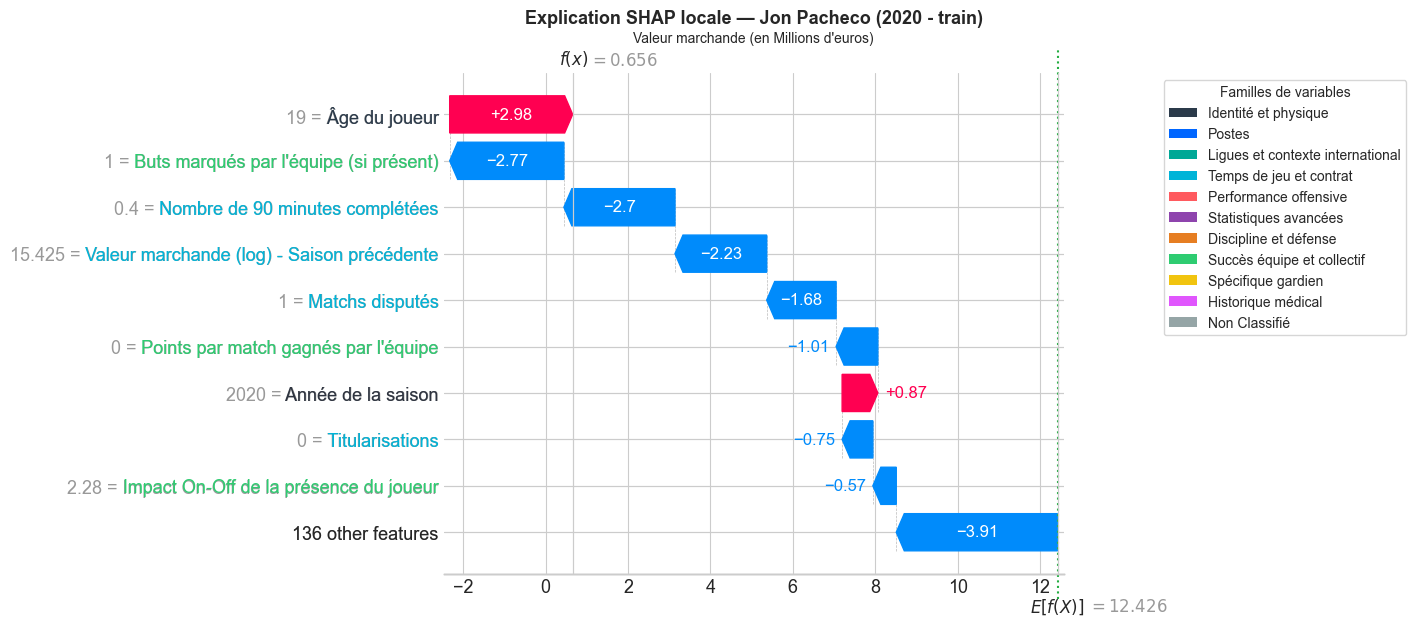

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


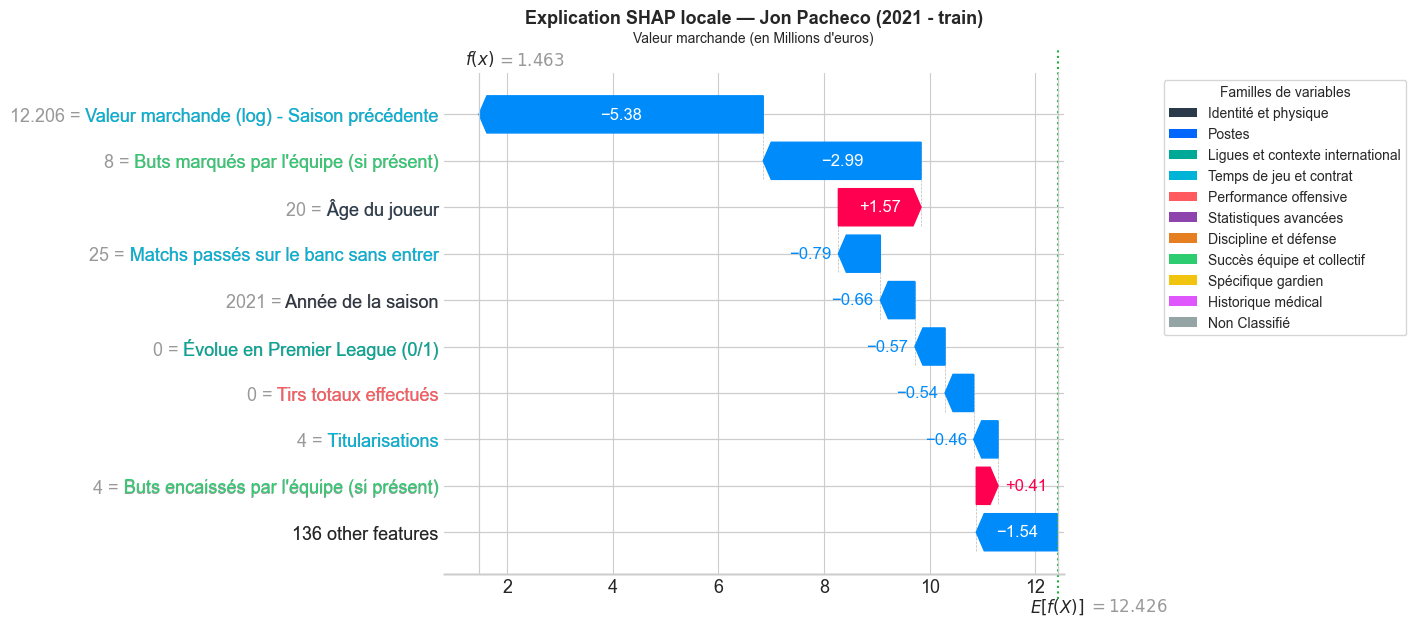

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


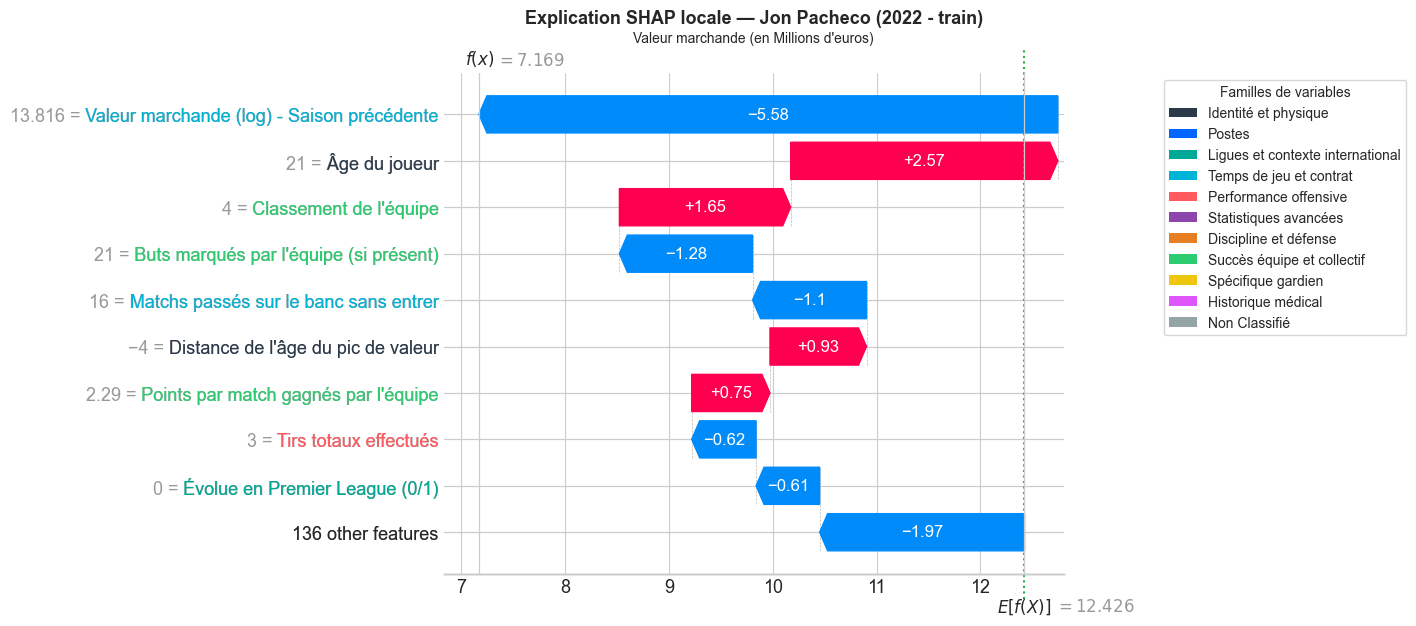

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


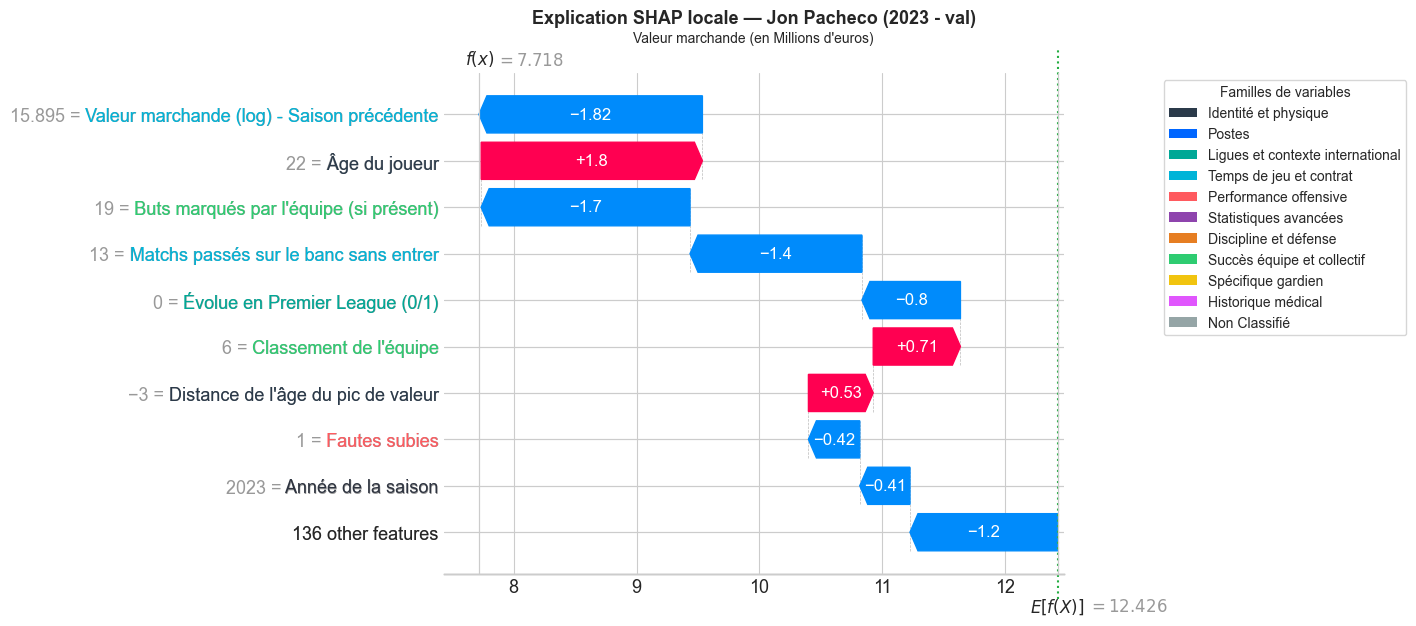

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


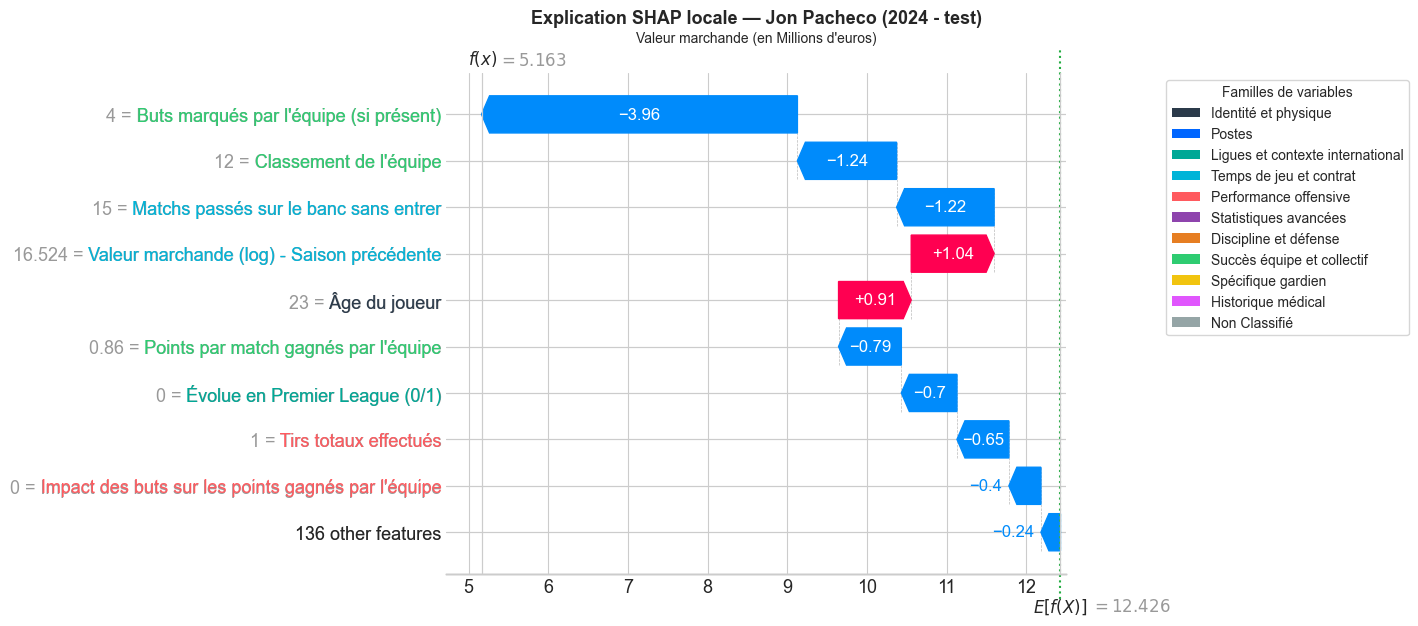

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\modelisations\explicabilite.py:1104: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  loc="upper left",


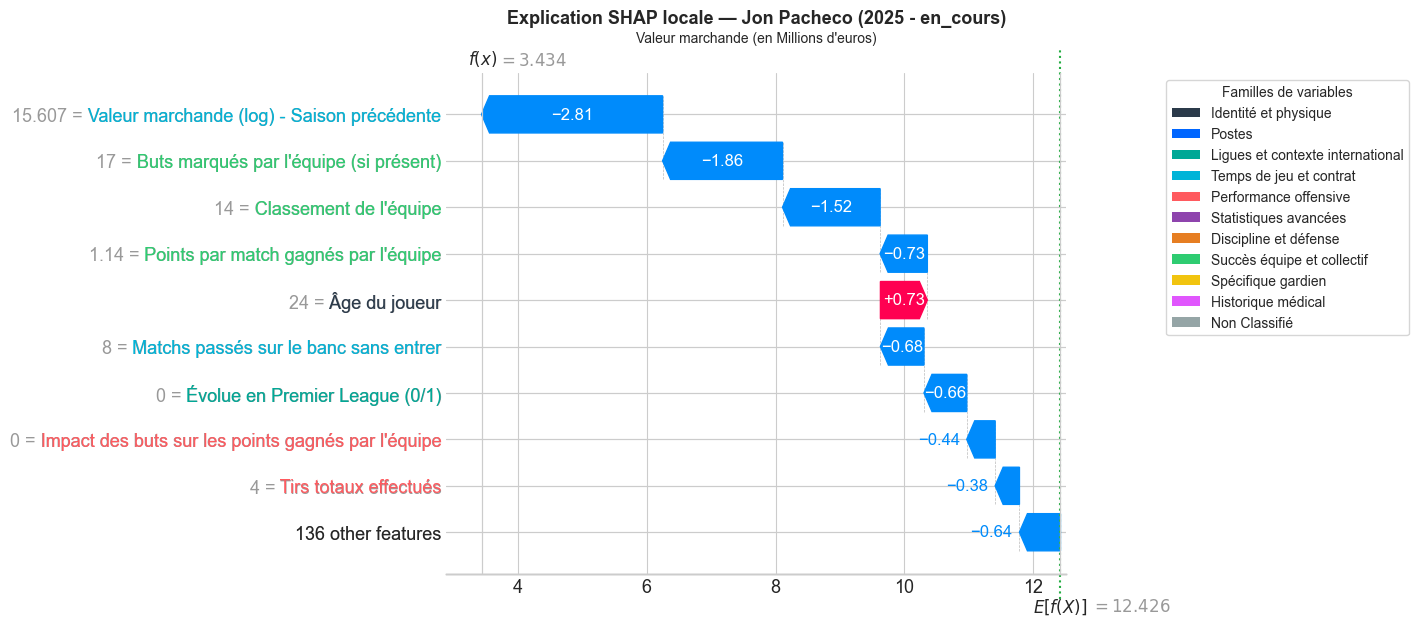

In [ ]:
res = analyser_explications_shap_joueur(
    joueur_etudie="Jon Pacheco",
    df_historique=df_historique,
    datasets_par_split=dict_datasets,
    modele_stack=modele_stack,
    X_train_bg=X_train,
    groupes=groupes,
    palette_pro=PALETTE_PRO,
)